Short study to evaluate if the fraud detection model is fair across demographic groups (gender and age).

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [ ]:
from transaction_analysis.models.features import build_features

X, y = build_features()

print(f"Shape: {X.shape}")
print(f"Fraud rate: {y.mean():.4f}")
print(f"\nGender stats:\n{X['gender'].value_counts()}")

Shape: (13305915, 47)
Fraud rate: 0.0010

Gender stats:
gender
0    6815916
1    6489999
Name: count, dtype: int64


In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=50000, replace=False)

X_sampled = X.iloc[sample_idx].reset_index(drop=True)
y_sampled = y.iloc[sample_idx].reset_index(drop=True)

# Gender is already numeric (0/1), no mapping needed
gender_sampled = X_sampled["gender"].astype(int)

print(f"Train shape: {X_sampled.shape}, Gender shape: {gender_sampled.shape}")
print(f"Gender value counts:\n{gender_sampled.value_counts()}")

X_sample = X_sampled.drop("gender", axis=1)

# Use stratified split to maintain gender distribution
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_sample, y_sampled, gender_sampled, test_size=0.3, random_state=42, stratify=gender_sampled
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Gender test - NaN count: {gender_test.isna().sum()}, unique values: {gender_test.unique()}")

Train shape: (50000, 47), Gender shape: (50000,)
Gender value counts:
gender
0    25635
1    24365
Name: count, dtype: int64
Train shape: (35000, 46), Test shape: (15000, 46)
Gender test - NaN count: 0, unique values: [1 0]


In [33]:
# Train baseline model
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Baseline accuracy: {(y_pred == y_test).mean():.4f}")

Baseline accuracy: 0.9993


In [34]:
# Create aif360 datasets for fairness analysis
# Gender: Male=0 (unprivileged), Female=1 (privileged)
test_df_gender = pd.DataFrame({"pred": y_pred, "true": y_test.values, "gender": gender_test.values})

dataset_gender = BinaryLabelDataset(
    df=test_df_gender,
    label_names=["true"],
    protected_attribute_names=["gender"],
    favorable_label=1,
    unfavorable_label=0,
)

print("Dataset created for fairness analysis")

Dataset created for fairness analysis


In [ ]:
# Fairness metrics for GENDER
metrics_gender = ClassificationMetric(
    dataset_gender, dataset_gender, unprivileged_groups=[{"gender": 0}], privileged_groups=[{"gender": 1}]
)

fairness_gender = {
    "Disparate Impact": metrics_gender.disparate_impact(),
    "Statistical Parity Difference": metrics_gender.statistical_parity_difference(),
    "Equal Opportunity Difference": metrics_gender.equal_opportunity_difference(),
    "Theil Index": metrics_gender.theil_index(),
}

print("=== FAIRNESS METRICS BY GENDER ===")
for metric, value in fairness_gender.items():
    print(f"{metric}: {value:.4f}")

print("\n[Notes]")
print("Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias")
print("Statistical Parity Difference ~0 = fair")
print("Equal Opportunity Difference ~0 = fair")

=== FAIRNESS METRICS BY GENDER ===
Disparate Impact: 0.6336
Statistical Parity Difference: -0.0003
Equal Opportunity Difference: 0.0000
Theil Index: 0.0000

[Notes]
Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias
Statistical Parity Difference ~0 = fair
Equal Opportunity Difference ~0 = fair


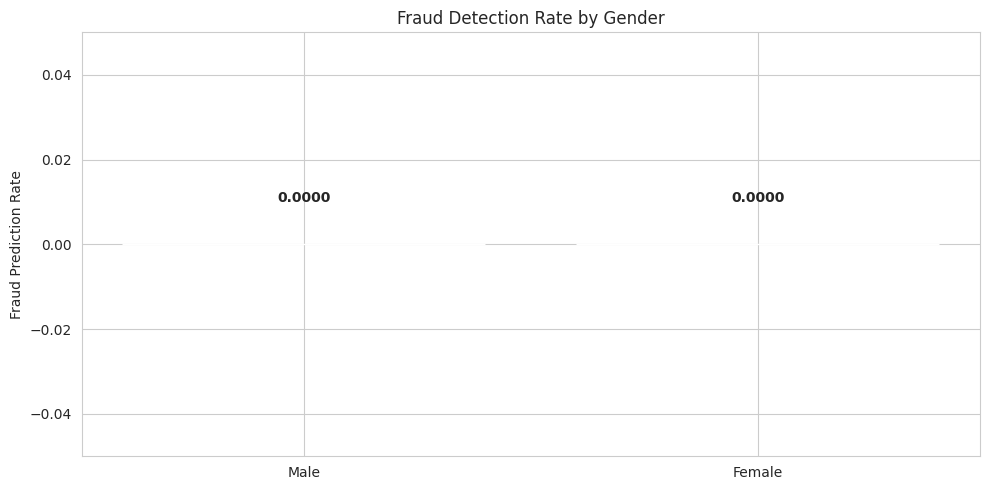

Prediction rate difference (Gender): 0.0000


In [ ]:
from transaction_analysis.config.paths import PLOTS_DIR

# Compare prediction rates across groups
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# By Gender
gender_names = {0: "Male", 1: "Female"}
pred_rate_gender = [y_pred[gender_test == g].mean() for g in [0, 1]]
ax.bar(list(gender_names.values()), pred_rate_gender, color=["steelblue", "coral"])
ax.set_ylabel("Fraud Prediction Rate")
ax.set_title("Fraud Detection Rate by Gender")
ax.set_ylim([0, max(pred_rate_gender) * 1.2])
for i, v in enumerate(pred_rate_gender):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fairness_prediction_rates.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Prediction rate difference (Gender): {abs(pred_rate_gender[0] - pred_rate_gender[1]):.4f}")

In [ ]:
# Summary
print("=" * 60)
print("FAIRNESS STUDY SUMMARY")
print("=" * 60)

# Gender fairness assessment
di_gender = fairness_gender["Disparate Impact"]
gender_status = "FAIR" if 0.8 <= di_gender <= 1.25 else "BIASED"

print(f"\nGender Fairness: {gender_status}")
print(f"  - Disparate Impact: {di_gender:.4f}")
print(
    f"  - Model predicts fraud at different rates for Male ({pred_rate_gender[0]:.10f})\
    vs Female ({pred_rate_gender[1]:.10f})"
)

print("\n" + "=" * 60)

FAIRNESS STUDY SUMMARY

Gender Fairness: BIASED
  - Disparate Impact: 0.6336
  - Model predicts fraud at different rates for Male (0.0000000000) vs Female (0.0000000000)

